In [2]:
import csv
import pandas as pd

In [3]:
main1 = pd.read_csv("Kappa_scores_Main1.csv", delimiter=",", encoding="utf-8")
main2 = pd.read_csv("Kappa_scores_Main2.csv", delimiter=",", encoding="utf-8")
main3 = pd.read_csv("Kappa_scores_Main3.csv", delimiter=",", encoding="utf-8")
#main4 = pd.read_csv("Kappa_scores_Main4.csv", delimiter=",", encoding="utf-8")
#main5 = pd.read_csv("Kappa_scores_Main5.csv", delimiter=",", encoding="utf-8")

In [4]:
main = pd.concat([main1, main2, main3], ignore_index=True)
main.to_csv("Main.csv")
main

,Phase,Type,6-level,3-level
0,Main1,full,0.71,0.83
1,Main1,non-procedural,0.63,0.78
2,Main2,full,0.67,0.84
3,Main2,non-procedural,0.47,0.69
4,Main3,full,0.75,0.89
5,Main3,non-procedural,0.61,0.81


In [5]:
data = pd.melt(main,
               id_vars=['Phase', 'Type'],
               value_vars=['6-level', '3-level'],
               var_name = 'Level',
               value_name = 'Kappa Score'
)

data

,Phase,Type,Level,Kappa Score
0,Main1,full,6-level,0.71
1,Main1,non-procedural,6-level,0.63
2,Main2,full,6-level,0.67
3,Main2,non-procedural,6-level,0.47
4,Main3,full,6-level,0.75
5,Main3,non-procedural,6-level,0.61
6,Main1,full,3-level,0.83
7,Main1,non-procedural,3-level,0.78
8,Main2,full,3-level,0.84
9,Main2,non-procedural,3-level,0.69


# Main annotation - Kappa score analysis

New data will be added gradually as the annotation phases progress. 

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

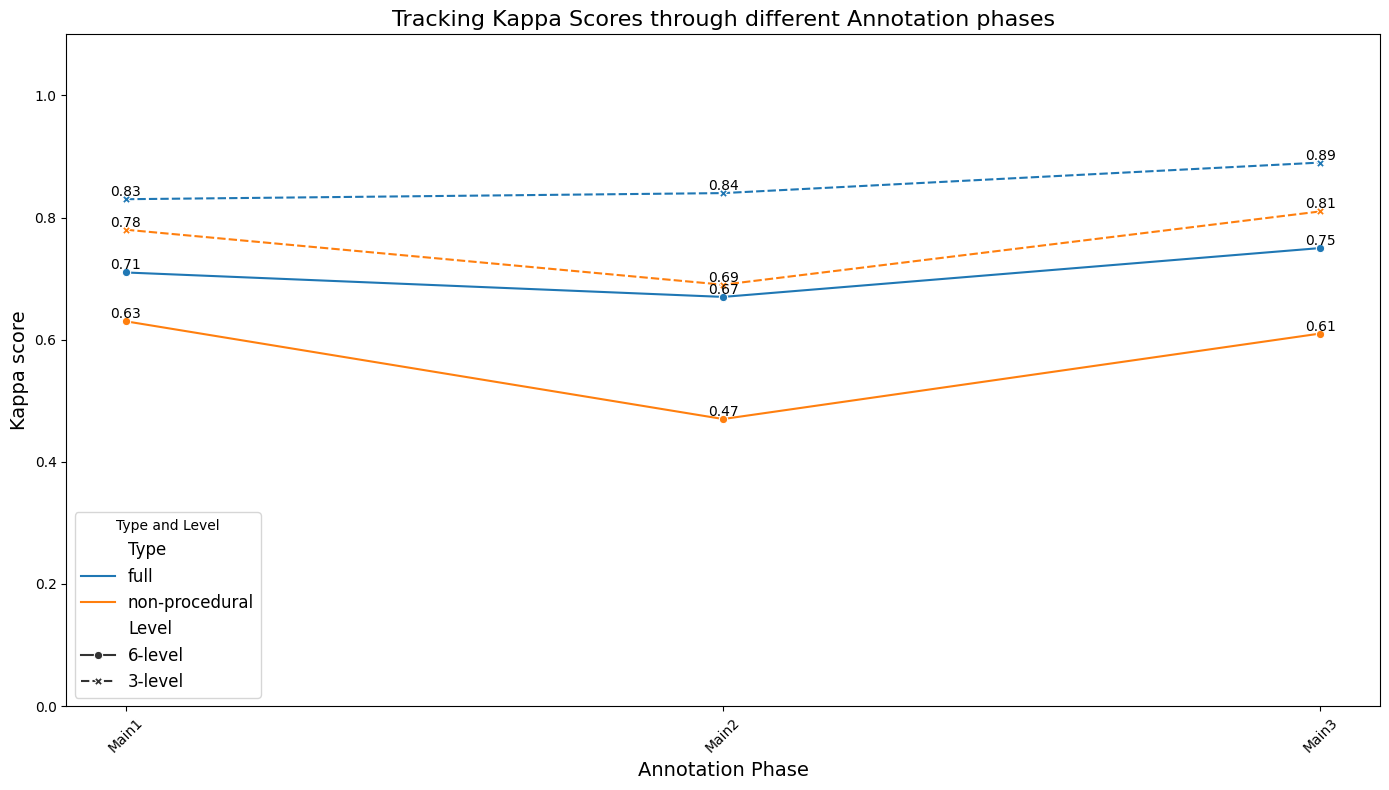

In [7]:
plt.figure(figsize=(14,8))
line_plot=sns.lineplot(data=data, x='Phase', y='Kappa Score', hue='Type', style='Level', markers=True, palette='tab10')

plt.title('Tracking Kappa Scores through different Annotation phases', fontsize=16)
plt.xlabel('Annotation Phase', fontsize=14)
plt.ylabel('Kappa score', fontsize=14)
plt.legend(title='Type and Level', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, 1.1)

for line in line_plot.lines:
    for x_data, y_data in zip(line.get_xdata(), line.get_ydata()):
        plt.text(x_data, y_data, f'{y_data:.2f}', fontsize=10, ha='center', va='bottom')


plt.tight_layout()
plt.show()

# Dataset analysis
Main annotation (consolidation files) analysis, checking the overall distribution of the labels

In [8]:
#Note, 25.9: Change the data1 with full dataset without missing two sentences.
data1 = pd.read_csv("Main1/Main1_dataset.csv", delimiter=";", encoding="utf-8")
data2 = pd.read_csv("Main2/Main2_dataset.csv", delimiter=";", encoding="utf-8")
data3 = pd.read_csv("Main3/Main3_dataset.csv", delimiter=";", encoding="utf-8")


In [9]:
data = pd.concat([data1, data2, data3], ignore_index=True)
data.head()

,ID,text,tag_tamara,tag_katja,comments_tamara,comments_katja,flagged_tamara,flagged_katja,sent_tamara,sent_katja,chair,final_tag
0,ParlaMint-SI_2010-09-07-SDZ5-Izredna-28.u90,"Ni replike na repliko. Gospa ministrica, potem...",N_Neutral,N_Neutral,"Procedural, but he is denying her the ability ...","Procedural, however still has relatively stron...",NaN,NaN,Neutral,Neutral,True,N_Neutral
1,ParlaMint-SI_2011-06-16-SDZ5-Redna-29.u107,Hvala lepa. Besedo ima Silva Črnugelj. Priprav...,P_Neutral,P_Neutral,Procedural.,NaN,NaN,NaN,Neutral,Neutral,True,P_Neutral
2,ParlaMint-SI_2011-06-21-SDZ5-Redna-29.u178,"Hvala lepa. V bistvu se strinjam z vami, gospo...",Positive,Positive,Speaker is stating positive changes and support.,"Speech seems to be fairly positive, as the spe...",NaN,NaN,Positive,Positive,False,Positive
3,ParlaMint-SI_2020-09-21-SDZ8-Redna-20.u276,"Hvala, podpredsednik. Hvala tudi za vprašanje,...",Negative,Negative,"Negative opinion of the topic, the work done, ...",Could also be Mixed sentiment due to the last ...,NaN,1.0,Negative,Negative,False,Negative
4,ParlaMint-SI_2009-11-18-SDZ5-Redna-11.u120,Besedo ima gospod Silven Majhenič.,P_Neutral,P_Neutral,Procedural,NaN,NaN,NaN,Neutral,Neutral,True,P_Neutral


## Final tag distribution 

In [10]:
import seaborn
import matplotlib.pyplot as plt

In [11]:
tags = data['final_tag'].value_counts()
tags

final_tag
P_Neutral     299
Negative      163
M_Positive     41
N_Neutral      38
Positive       35
M_Negative     24
Name: count, dtype: int64

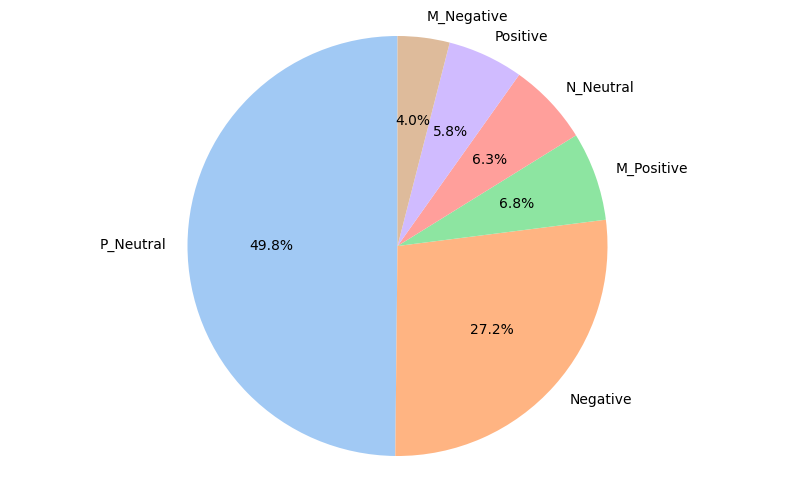

In [17]:
palette = sns.color_palette('pastel')
plt.figure(figsize=(10,6))
plt.pie(tags, labels=tags.index, colors=palette, autopct='%1.1f%%', startangle=90)
plt.axis('equal')
plt.show()

In [13]:
tags_non = data[data['chair'] == False]
tags_non = tags_non.value_counts('final_tag')
tags_non

final_tag
Negative      154
M_Positive     41
Positive       35
M_Negative     24
P_Neutral      21
N_Neutral      13
Name: count, dtype: int64

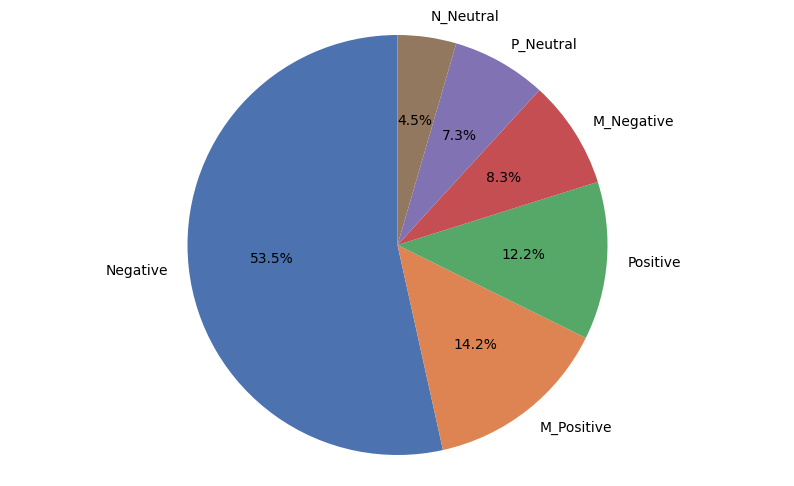

In [41]:
palette2 = sns.color_palette('deep')
plt.figure(figsize=(10,6))
plt.pie(tags_non, labels=tags_non.index, colors=palette2, autopct='%1.1f%%', startangle=90)
plt.axis('equal')
plt.show()

In [15]:
tags_proced = data[data['chair'] != False]
tags_proced = tags_proced.value_counts('final_tag')
tags_proced

final_tag
P_Neutral    278
N_Neutral     25
Negative       9
Name: count, dtype: int64

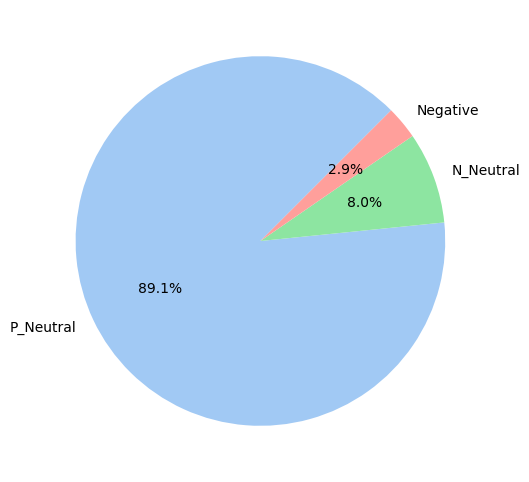

In [43]:
palette3 = sns.color_palette('pastel6')
plt.figure(figsize=(10,6))
plt.pie(tags_proced, labels=tags_proced.index, colors=palette3, autopct='%1.1f%%', startangle=45)
plt.show()